# When Bonds Stop Diversifying

## 1. Market Data and Portfolio Construction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm

from matplotlib.lines import Line2D

In [96]:
ticker = "IMAE.AS" 
#用一只欧洲股票 ETF：iShares Core MSCI Europe UCITS ETF 在 Yahoo Finance 上的日频市场数据。
# 它追踪 MSCI Europe，覆盖欧洲发达市场的大中型股票，比只用 EURO STOXX 50 更能代表“欧洲股票”

In [97]:
stock = yf.download(
    ticker,
    start="2018-01-01",
    end="2026-08-01",
    auto_adjust=True,
    progress=False
)

In [98]:
stock.head() #前 5 行数据
#Date：交易日期 Open：当天开盘价 High：当天最高价 Low：当天最低价 Close：当天收盘价 Volume：当天成交量
#对于这个项目，最重要的是 Close，因为后面会用每日收盘价计算日收益率。

Price,Close,High,Low,Open,Volume
Ticker,IMAE.AS,IMAE.AS,IMAE.AS,IMAE.AS,IMAE.AS
Date,,,,,
2018-01-02,49.580002,49.599998,49.415001,49.560001,3928
2018-01-03,49.840000,49.924999,49.685001,49.794998,5680
2018-01-04,50.255001,50.340000,50.080002,50.119999,21420
2018-01-05,50.720001,50.720001,50.430000,50.455002,37584
2018-01-08,50.845001,50.959999,50.799999,50.959999,22337


In [99]:
# 计算欧洲股票ETF的每日收益率，用收益率算股票每天的涨跌和债券每天的涨跌之间的correlation
#.pct_change() 是计算相邻两个交易日之间的百分比变化（return）
stock_return = stock["Close"].pct_change()

In [100]:
stock_return.head()
#第一行NaN，因为没有更早的，无法计算Rt=(Pt-Pt-1)/Pt-1

Ticker,IMAE.AS
Date,
2018-01-02,NaN
2018-01-03,0.005244
2018-01-04,0.008327
2018-01-05,0.009253
2018-01-08,0.002465


In [101]:
# Yahoo Finance 上欧元区政府债券ETF的ticker：Shares € Govt Bond 7–10yr UCITS ETF，期限大约 7–10 年，比较适合拿来代表“中长期欧元区政府债券”这一块。
bond_ticker = "IBGM.AS"

In [102]:
# 下载2018-2026欧元区政府债券ETF数据
bond = yf.download(
    bond_ticker,
    start="2018-01-01",
    end="2026-08-01",
    auto_adjust=True,
    progress=False
)

In [103]:
bond.head()

Price,Close,High,Low,Open,Volume
Ticker,IBGM.AS,IBGM.AS,IBGM.AS,IBGM.AS,IBGM.AS
Date,,,,,
2018-01-02,188.090698,188.531133,188.090698,188.531133,25409
2018-01-03,188.441269,188.531158,188.270501,188.270501,642
2018-01-04,188.827774,188.827774,188.162629,188.252519,2709
2018-01-05,188.818817,189.061493,188.657019,188.657019,1149
2018-01-08,189.097412,189.295157,188.594065,188.594065,9469


In [104]:
# 计算欧元区政府债券ETF的每日收益率
bond_return = bond["Close"].pct_change()
bond_return.head()

Ticker,IBGM.AS
Date,
2018-01-02,NaN
2018-01-03,0.001864
2018-01-04,0.002051
2018-01-05,-0.000047
2018-01-08,0.001475


In [105]:
# 把股票和债券的每日收益率合并到同一张表
returns = stock_return.join(
    bond_return,
    lsuffix="_stock",
    rsuffix="_bond"
   
)
returns.columns = ["Stock", "Bond"]
returns.head()

,Stock,Bond
Date,,
2018-01-02,NaN,NaN
2018-01-03,0.005244,0.001864
2018-01-04,0.008327,0.002051
2018-01-05,0.009253,-0.000047
2018-01-08,0.002465,0.001475


In [106]:
# 删除缺失收益率的日期
returns = returns.dropna()
returns.head()


,Stock,Bond
Date,,
2018-01-03,0.005244,0.001864
2018-01-04,0.008327,0.002051
2018-01-05,0.009253,-0.000047
2018-01-08,0.002465,0.001475
2018-01-09,0.004229,-0.002472


In [107]:
# 计算整个样本期股票和债券收益率的平均correlation
overall_corr = returns["Stock"].corr(returns["Bond"])

overall_corr

0.14316149818218962

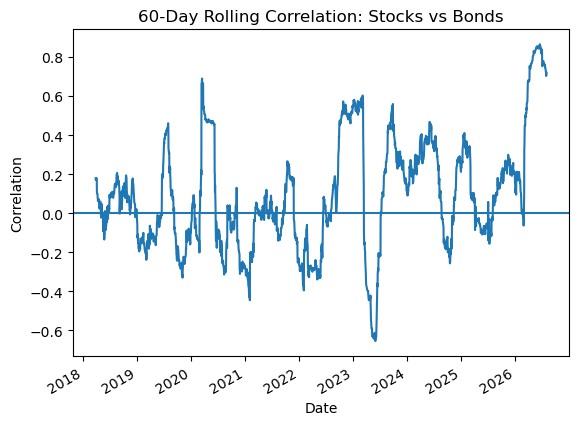

In [108]:
# 计算60个交易日滚动相关性（为了回答：正常时期相关性是多少？高通胀/加息时期是不是变高了？1-60天计算一次，2-61天计算一次，以此类推）
rolling_corr = returns["Stock"].rolling(60).corr(
    returns["Bond"]
)
# 画60日滚动股票-债券相关性
rolling_corr.plot()

plt.axhline(0) #画一条水平线在 y=0，方便观察相关性是正还是负（correlation < 0：股票和债券更倾向反向运动，diversification 更强）
plt.title("60-Day Rolling Correlation: Stocks vs Bonds")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.show()

In [109]:
# 计算股票和债券的累计表现
cumulative_returns = (1 + returns).cumprod()
cumulative_returns.head()

,Stock,Bond
Date,,
2018-01-03,1.005244,1.001864
2018-01-04,1.013614,1.003919
2018-01-05,1.022993,1.003871
2018-01-08,1.025514,1.005352
2018-01-09,1.029851,1.002868


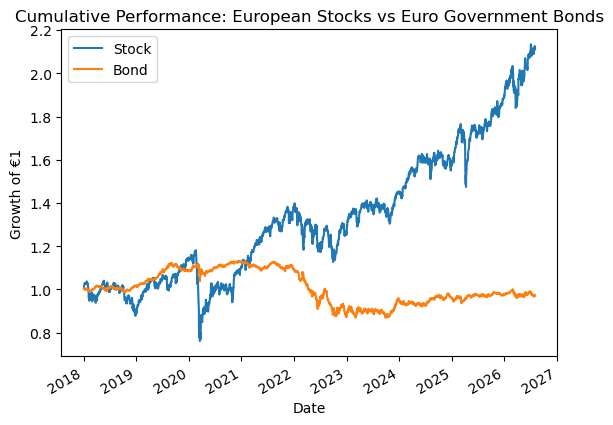

In [110]:
cumulative_returns.plot() #2018 年分别投资 €1 股票和 €1 债券，之后分别会变成多少钱？
plt.title("Cumulative Performance: European Stocks vs Euro Government Bonds")
plt.xlabel("Date")
plt.ylabel("Growth of €1")
plt.show()
#图中可以看出2020年分散化起作用，但2022年高通胀/加息时期，股票和债券都下跌，分散化作用减弱


In [111]:
# 计算60/40组合（60%投资股票，40%投资债券）的每日收益率
returns["Portfolio_60_40"] = (
    0.6 * returns["Stock"]
    + 0.4 * returns["Bond"]
)
returns.head()

,Stock,Bond,Portfolio_60_40
Date,,,
2018-01-03,0.005244,0.001864,0.003892
2018-01-04,0.008327,0.002051,0.005816
2018-01-05,0.009253,-0.000047,0.005533
2018-01-08,0.002465,0.001475,0.002069
2018-01-09,0.004229,-0.002472,0.001549


In [112]:
# 计算股票、债券和60/40组合的累计表现
cumulative_all = (1 + returns).cumprod()
cumulative_all.head()

,Stock,Bond,Portfolio_60_40
Date,,,
2018-01-03,1.005244,1.001864,1.003892
2018-01-04,1.013614,1.003919,1.009731
2018-01-05,1.022993,1.003871,1.015318
2018-01-08,1.025514,1.005352,1.017418
2018-01-09,1.029851,1.002868,1.018994


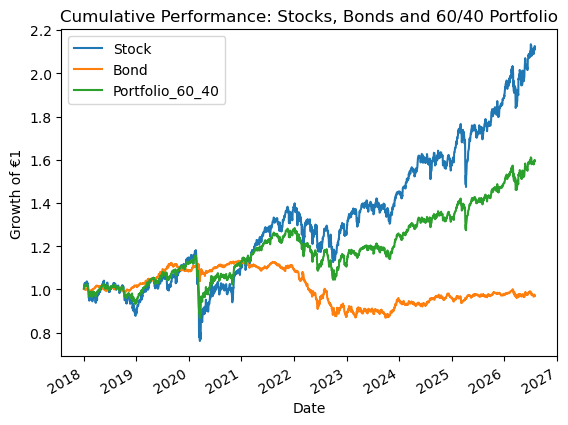

In [113]:
# 比较股票、债券和60/40组合的累计表现
cumulative_all.plot()

plt.title("Cumulative Performance: Stocks, Bonds and 60/40 Portfolio")
plt.xlabel("Date")
plt.ylabel("Growth of €1")
plt.show()
#债券和股票不同步,比如2020年→ 60/40 更平稳。
#某些宏观压力时期，比如2022年高通胀/加息时期：股票和债券一起跌 → 60/40 仍然跌得不少 → diversification failure。

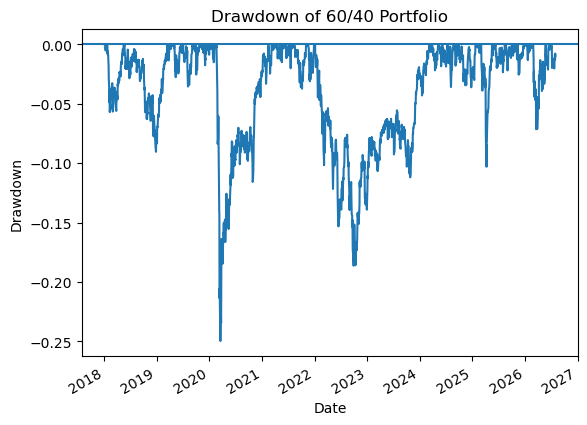

In [114]:
# 计算60/40组合到每一天为止的历史最高值
portfolio_peak = cumulative_all["Portfolio_60_40"].cummax()
# 计算60/40组合的drawdown（drawdown = 当前值 / 历史最高值 - 1，负数表示亏损）
portfolio_drawdown = (
    cumulative_all["Portfolio_60_40"] / portfolio_peak
    - 1
)
portfolio_drawdown.plot()

plt.title("Drawdown of 60/40 Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.axhline(0)
plt.show()

In [115]:
max_drawdown_60_40 = portfolio_drawdown.min()

max_drawdown_60_40

-0.24972813131513671

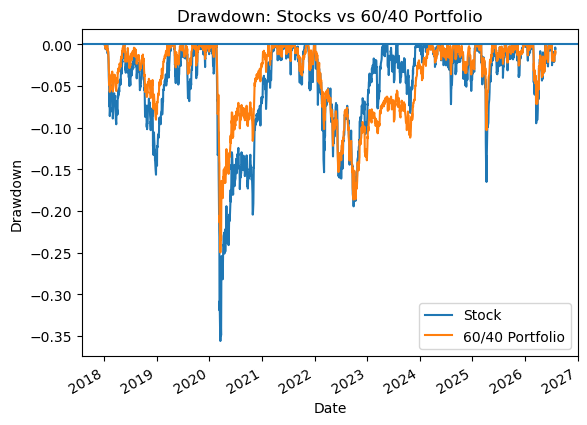

In [116]:
# 计算股票累计表现到每一天为止的历史最高值
stock_peak = cumulative_all["Stock"].cummax()

# 计算股票drawdown
stock_drawdown = (
    cumulative_all["Stock"] / stock_peak
    - 1
)
# 比较股票和60/40组合的drawdown
stock_drawdown.plot(label="Stock")
portfolio_drawdown.plot(label="60/40 Portfolio")

plt.title("Drawdown: Stocks vs 60/40 Portfolio")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.axhline(0)
plt.legend()
plt.show()

In [117]:
max_drawdown_stock = stock_drawdown.min()

max_drawdown_stock
#说明最严重时期 60/40 确实明显减少了损失。不过这还是“整个 2018–2026 的最大回撤”。下面我们单独比较 2020 crisis 和 2022 inflation/rate-shock period 的 drawdown

-0.3559784905375841

In [118]:
# 只看2020年
period_2020 = cumulative_all.loc["2020-01-01":"2020-12-31"]

# 2020年股票 max drawdown
stock_dd_2020 = (
    period_2020["Stock"]
    / period_2020["Stock"].cummax()
    - 1
).min()

# 2020年 60/40 max drawdown
portfolio_dd_2020 = (
    period_2020["Portfolio_60_40"]
    / period_2020["Portfolio_60_40"].cummax()
    - 1
).min()

stock_dd_2020, portfolio_dd_2020

(-0.3559784905375841, -0.24972813131513671)

In [119]:
# 只看2022年
period_2022 = cumulative_all.loc["2022-01-01":"2022-12-31"]

# 2022年股票 max drawdown
stock_dd_2022 = (
    period_2022["Stock"]
    / period_2022["Stock"].cummax()
    - 1
).min()

# 2022年 60/40 max drawdown
portfolio_dd_2022 = (
    period_2022["Portfolio_60_40"]
    / period_2022["Portfolio_60_40"].cummax()
    - 1
).min()

stock_dd_2022, portfolio_dd_2022

(-0.19444639482066317, -0.18635408423071953)

## 2. Macro Regimes and Descriptive Evidence

In [120]:
inflation = pd.read_csv("../data/raw/ECB Data Portal_20260817160023.csv")
inflation.head()
#图表含义：e.g. 1997年1月欧元区总体消费价格水平，比1996年1月高约 2.1%

,DATE,TIME PERIOD,HICP Inflation rate - Total - Annual rate of change (HICP.M.U2.N.000000.4D0.ANR)
0,1996-12-31,1996Dec,NaN
1,1997-01-31,1997Jan,2.1
2,1997-02-28,1997Feb,1.8
3,1997-03-31,1997Mar,1.5
4,1997-04-30,1997Apr,1.3


In [121]:
inflation.tail()

,DATE,TIME PERIOD,HICP Inflation rate - Total - Annual rate of change (HICP.M.U2.N.000000.4D0.ANR)
351,2026-03-31,2026Mar,2.6
352,2026-04-30,2026Apr,3.0
353,2026-05-31,2026May,3.2
354,2026-06-30,2026Jun,2.8
355,2026-07-31,2026Jul,2.9


In [122]:
inflation.columns = ["Date", "Time_Period", "Inflation"]
inflation.head()

,Date,Time_Period,Inflation
0,1996-12-31,1996Dec,NaN
1,1997-01-31,1997Jan,2.1
2,1997-02-28,1997Feb,1.8
3,1997-03-31,1997Mar,1.5
4,1997-04-30,1997Apr,1.3


In [123]:
inflation["Date"] = pd.to_datetime(inflation["Date"])#把 Date 列字符串转换为 datetime 日期时间 类型，方便后续按时间索引和绘图
inflation.dtypes

Date           datetime64[ns]
Time_Period            object
Inflation             float64
dtype: object

In [124]:
inflation = pd.read_csv(
    "../data/raw/ECB Data Portal_20260817160023.csv"
)

inflation.columns = [
    "Date",
    "Time_Period",
    "Inflation"
]

inflation["Date"] = pd.to_datetime(
    inflation["Date"]
)

inflation = inflation[
    ["Date", "Inflation"]
]

inflation = inflation[
    inflation["Date"] >= "2018-01-01"
]

inflation = inflation.set_index("Date")

inflation.head()

,Inflation
Date,
2018-01-31,1.3
2018-02-28,1.1
2018-03-31,1.4
2018-04-30,1.2
2018-05-31,2.0


In [125]:
inflation.index

DatetimeIndex(['2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31',
               ...
               '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31',
               '2026-02-28', '2026-03-31', '2026-04-30', '2026-05-31',
               '2026-06-30', '2026-07-31'],
              dtype='datetime64[ns]', name='Date', length=103, freq=None)

In [126]:
# Map monthly HICP observations to all trading days in the same calendar month

inflation_monthly = inflation.copy()

# Convert monthly dates to monthly periods
inflation_monthly.index = inflation_monthly.index.to_period("M")

# Map each trading day in returns to its corresponding calendar month
return_months = returns.index.to_period("M")

# Assign that month's inflation value to each trading day
returns["Inflation"] = return_months.map(inflation_monthly["Inflation"])
returns[["Inflation"]].loc["2022-06-01":"2022-08-05"].head(50)

,Inflation
Date,
2022-06-01,8.6
2022-06-02,8.6
2022-06-03,8.6
2022-06-06,8.6
2022-06-07,8.6
2022-06-08,8.6
2022-06-09,8.6
2022-06-10,8.6
2022-06-13,8.6


In [127]:
returns["Inflation"].describe()

count    2194.000000
mean        2.995351
std         2.606745
min        -0.300000
25%         1.400000
50%         2.200000
75%         3.200000
max        10.600000
Name: Inflation, dtype: float64

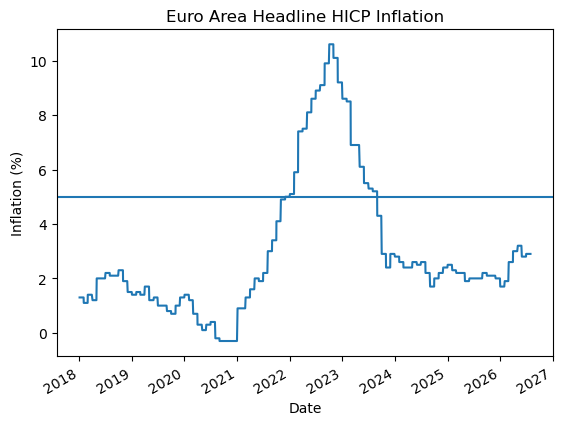

In [128]:
returns["Inflation"].plot()

plt.title("Euro Area Headline HICP Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.axhline(5)
plt.show()

In [129]:
valid_inflation = returns["Inflation"].notna()
returns["High_Inflation"] = returns["Inflation"] > 5
returns["High_Inflation"].value_counts() #检查样本量够不够，如果不够，会受偶然波动影响。

False    1766
True      428
Name: High_Inflation, dtype: int64

In [130]:
high_inflation_corr = returns.loc[
    valid_inflation & returns["High_Inflation"],
    "Stock" #只取 High_Inflation == True 的日期，然后只拿 Stock 这一列
].corr(
    returns.loc[
        valid_inflation & returns["High_Inflation"],
        "Bond"
    ]
)
#计算Corr(Stock, Bond | High_Inflation = True)
high_inflation_corr

0.06594685445624626

In [131]:
normal_inflation_corr = returns.loc[
valid_inflation & ~returns["High_Inflation"],#～表示取反，也就是 High_Inflation == False 的日期
    "Stock"
].corr(
    returns.loc[
        valid_inflation & ~returns["High_Inflation"],
        "Bond"
    ]
)
normal_inflation_corr

0.19440524003404602

In [132]:
print("High Inflation Correlation:", high_inflation_corr)
print("Normal Inflation Correlation:", normal_inflation_corr)
#inflation level 本身可能不是足够好的 regime 定义,因为normal inflation时bond和stock的correlation比high inflation高，所以我们需要引入第二个宏观变量ECB policy rate。

High Inflation Correlation: 0.06594685445624626
Normal Inflation Correlation: 0.19440524003404602


In [133]:
ecb_rate = pd.read_csv("../data/raw/ECB Data Portal_20260818182339.csv")
ecb_rate.head()

,DATE,TIME PERIOD,Deposit facility - date of changes (raw data) - Level (FM.D.U2.EUR.4F.KR.DFR.LEV)
0,1999-01-01,01 Jan 1999,2.00
1,1999-01-02,02 Jan 1999,2.00
2,1999-01-03,03 Jan 1999,2.00
3,1999-01-04,04 Jan 1999,2.75
4,1999-01-05,05 Jan 1999,2.75


In [134]:
ecb_rate.columns = ["Date", "Time_Period", "ECB_Rate"]
ecb_rate["Date"] = pd.to_datetime(ecb_rate["Date"])
ecb_rate = ecb_rate[["Date", "ECB_Rate"]]
ecb_rate = ecb_rate[ecb_rate["Date"] >= "2018-01-01"]
ecb_rate.head()

,Date,ECB_Rate
6940,2018-01-01,-0.4
6941,2018-01-02,-0.4
6942,2018-01-03,-0.4
6943,2018-01-04,-0.4
6944,2018-01-05,-0.4


In [135]:
ecb_rate.tail()

,Date,ECB_Rate
10087,2026-08-14,2.25
10088,2026-08-15,2.25
10089,2026-08-16,2.25
10090,2026-08-17,2.25
10091,2026-08-18,2.25


In [136]:
ecb_rate = ecb_rate.set_index("Date")
ecb_rate_daily = ecb_rate.reindex(returns.index)
ecb_rate_daily.isna().sum()

ECB_Rate    0
dtype: int64

In [137]:
returns["ECB_Rate"] = ecb_rate_daily["ECB_Rate"]
returns.head()

,Stock,Bond,Portfolio_60_40,Inflation,High_Inflation,ECB_Rate
Date,,,,,,
2018-01-03,0.005244,0.001864,0.003892,1.3,False,-0.4
2018-01-04,0.008327,0.002051,0.005816,1.3,False,-0.4
2018-01-05,0.009253,-0.000047,0.005533,1.3,False,-0.4
2018-01-08,0.002465,0.001475,0.002069,1.3,False,-0.4
2018-01-09,0.004229,-0.002472,0.001549,1.3,False,-0.4


In [138]:
returns.loc["2022-06-01":"2022-12-31", ["Inflation", "ECB_Rate"]]

,Inflation,ECB_Rate
Date,,
2022-06-01,8.6,-0.5
2022-06-02,8.6,-0.5
2022-06-03,8.6,-0.5
2022-06-06,8.6,-0.5
2022-06-07,8.6,-0.5
...,...,...
2022-12-23,9.2,2.0
2022-12-27,9.2,2.0
2022-12-28,9.2,2.0


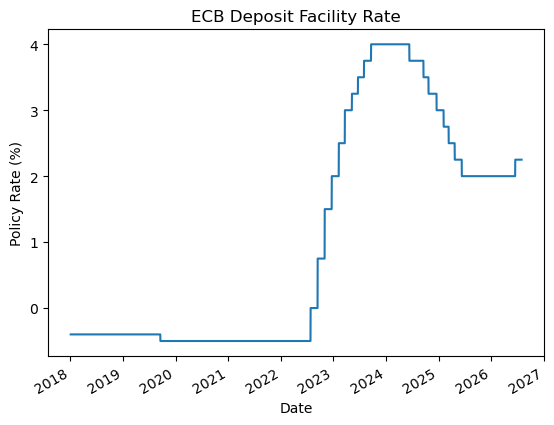

In [139]:
returns["ECB_Rate"].plot()

plt.title("ECB Deposit Facility Rate")
plt.xlabel("Date")
plt.ylabel("Policy Rate (%)")
plt.show()

In [140]:
returns["ECB_Rate_Change"] = returns["ECB_Rate"].diff() #计算每日政策利率变化,看ECB是不是在加息（diff() 是计算相邻两个交易日之间的差值）
rate_change_mask = (
    returns["ECB_Rate_Change"].notna()
    & returns["ECB_Rate_Change"].ne(0)
)

rate_changes = returns.loc[
    rate_change_mask,
    ["ECB_Rate", "ECB_Rate_Change"]
   
#在 returns 表中筛选出 ECB_Rate_Change 不为 0 的日期，并只显示 ECB_Rate 和 ECB_Rate_Change 两列

]

rate_changes

#Hiking Regime 暂时定义成：2022-07-27≤Date≤2023-09-20，这整个区间处于持续 tightening cycle 中。


,ECB_Rate,ECB_Rate_Change
Date,,
2019-09-18,-0.50,-0.10
2022-07-27,0.00,0.50
2022-09-14,0.75,0.75
2022-11-02,1.50,0.75
2022-12-21,2.00,0.50
2023-02-08,2.50,0.50
2023-03-22,3.00,0.50
2023-05-10,3.25,0.25
2023-06-21,3.50,0.25


In [141]:
returns["Hiking_Regime"] = (
    (returns.index >= "2022-07-27")
    & (returns.index <= "2023-09-20")
)
hiking_corr = returns.loc[
    returns["Hiking_Regime"],
    "Stock"
].corr(
    returns.loc[
        returns["Hiking_Regime"],
        "Bond"
    ]
)
hiking_corr
#现在算得是Corr(Stock, Bond | Hiking_Regime = True)，也就是在加息周期中股票和债券的相关性。

0.2237528200997429

In [142]:
non_hiking_corr = returns.loc[
    ~returns["Hiking_Regime"],
    "Stock"
].corr(
    returns.loc[
        ~returns["Hiking_Regime"],
        "Bond"
    ]
)
non_hiking_corr


0.133454521206464

In [143]:
print("Hiking Correlation:", hiking_corr)
print("Non-Hiking Correlation:", non_hiking_corr)
print("Difference:", hiking_corr - non_hiking_corr)
#得出结论：在 ECB 持续加息阶段，stock–bond correlation 更高。

Hiking Correlation: 0.2237528200997429
Non-Hiking Correlation: 0.133454521206464
Difference: 0.0902982988932789


在 Hiking Regime 里，股票和 60/40 的平均日收益分别是多少？

In [144]:
inflation_2020 = returns.loc["2020", "Inflation"].mean()
inflation_2022 = returns.loc["2022", "Inflation"].mean()
inflation_2020, inflation_2022
#可以看出2020 是低通胀环境，2022 是极高通胀环境。

(0.24785992217898842, 8.393774319066146)

In [145]:
rate_2020 = returns.loc["2020", "ECB_Rate"].mean()
rate_2022 = returns.loc["2022", "ECB_Rate"].mean()
rate_2020, rate_2022

(-0.5, 0.07879377431906615)

In [146]:
corr_2020 = returns.loc["2020", "Stock"].corr(returns.loc["2020", "Bond"])
corr_2022 = returns.loc["2022", "Stock"].corr(returns.loc["2022", "Bond"])
corr_2020, corr_2022

(0.29526791124611923, 0.12126704660136797)

In [147]:
#2020 和 2022 期间，债券自己分别跌了多少
bond_dd_2020 = (
    period_2020["Bond"]
    / period_2020["Bond"].cummax()
    - 1
).min()
bond_dd_2022 = (
    period_2022["Bond"]
    / period_2022["Bond"].cummax()
    - 1
).min()
bond_dd_2020,bond_dd_2022

(-0.07286024899231802, -0.19908637046033495)

### Key Finding: Diversification Is Not Correlation Alone

The initial hypothesis was that higher inflation would lead to higher
stock–bond correlation and therefore weaker diversification.

However, the sample does not support this simple explanation.

- High-inflation correlation is lower than normal-inflation correlation.
- Correlation is somewhat higher during the ECB hiking regime.
- Yet 2020 stock–bond correlation is higher than in 2022.

The strongest difference between 2020 and 2022 is bond downside:
bonds experienced only a relatively small drawdown in 2020, but a
large drawdown in 2022.

This suggests that diversification protection depends not only on
stock–bond correlation, but also on the severity of bond losses.

## 3. Statistical Evidence: ECB Hiking Regime

### 3.1 Research Question

Is the stock–bond return relationship statistically different during the ECB hiking regime?

The purpose of this section is to test whether the descriptive difference previously observed between hiking and non-hiking periods has statistical support.

The analysis focuses on statistical association rather than causal inference.

In [148]:
# Pre-regression data check

# 1. Check whether statsmodels is available
try:
    print("statsmodels is available.")
except ImportError:
    print("statsmodels is NOT installed.")

# 2. Create a hiking dummy
returns["Hiking"] = (
    (returns.index >= "2022-07-27") &
    (returns.index <= "2023-09-20")
).astype(int) #把True → 1，False → 0

# 3. Keep only the variables needed for Part 2.2
reg_data = returns[
    ["Stock", "Bond", "Hiking"]
].dropna() #regression 只保留 Stock、Bond、Hiking 三个变量都有效的日期

# 4. Basic checks
print("\nRegression sample size:")
print(len(reg_data))

print("\nMissing values:")
print(reg_data.isna().sum())

print("\nHiking dummy counts:")
print(reg_data["Hiking"].value_counts())

print("\nFirst few rows:")
display(reg_data.head())

print("\nLast few rows:")
display(reg_data.tail())

print("\nDescriptive stock-bond correlation by regime:")
print(
    reg_data.groupby("Hiking")
    .apply(lambda x: x["Stock"].corr(x["Bond"]))
)

statsmodels is available.

Regression sample size:
2194

Missing values:
Stock     0
Bond      0
Hiking    0
dtype: int64

Hiking dummy counts:
0    1897
1     297
Name: Hiking, dtype: int64

First few rows:


,Stock,Bond,Hiking
Date,,,
2018-01-03,0.005244,0.001864,0
2018-01-04,0.008327,0.002051,0
2018-01-05,0.009253,-0.000047,0
2018-01-08,0.002465,0.001475,0
2018-01-09,0.004229,-0.002472,0



Last few rows:


,Stock,Bond,Hiking
Date,,,
2026-07-27,0.000096,0.003781,0
2026-07-28,0.004211,0.002074,0
2026-07-29,-0.003860,-0.004467,0
2026-07-30,0.008275,0.000274,0
2026-07-31,-0.001565,-0.002407,0



Descriptive stock-bond correlation by regime:
Hiking
0    0.133455
1    0.223753
dtype: float64


In [149]:
# Model 1: Baseline regression

# Add a constant for the intercept alpha
X_baseline = sm.add_constant(reg_data["Stock"]) #在 Stock 这一列前加一列常数项1，这样 regression 才能估计截距项α

# Dependent variable
y = reg_data["Bond"]

# Estimate OLS regression
# Model 1: Bond return = α + β * Stock return + ε
model_1 = sm.OLS(y, X_baseline).fit() #找一条最合适的 regression line，让所有 observation 到这条线的 squared errors 尽可能小

# Show regression results
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                   Bond   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     45.87
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.62e-11
Time:                        20:50:41   Log-Likelihood:                 9002.9
No. Observations:                2194   AIC:                        -1.800e+04
Df Residuals:                    2192   BIC:                        -1.799e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.869e-05   8.54e-05     -0.336      0.7

The purpose of this model is to estimate the average contemporaneous relationship between stock and bond daily returns across the full sample.This model is only a baseline and does not yet test whether the relationship changes during the ECB hiking regime.

- Stock coefficient(β) = 0.0579

The estimated coefficient is positive. This means that, on average, higher stock returns are associated with higher bond returns.

- R² = 0.021

Stock returns explain approximately 2.1% of the daily variation in bond returns.

In [150]:
# Model 2: Hiking interaction regression

# Create interaction term
reg_data["Stock_x_Hiking"] = reg_data["Stock"] * reg_data["Hiking"]

# Independent variables
X_interaction = reg_data[
    ["Stock", "Hiking", "Stock_x_Hiking"]
]

# Add intercept
X_interaction = sm.add_constant(X_interaction)

# Estimate regression
#model 2: Bond return = α + β1 * Stock return + β2 * Hiking dummy + β3 * (Stock return × Hiking dummy) + ε
model_2 = sm.OLS(
    reg_data["Bond"],
    X_interaction
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 5}
)

# Show results
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                   Bond   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     2.349
Date:                Tue, 01 Sep 2026   Prob (F-statistic):             0.0707
Time:                        20:50:41   Log-Likelihood:                 9013.7
No. Observations:                2194   AIC:                        -1.802e+04
Df Residuals:                    2190   BIC:                        -1.800e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           2.468e-05   8.12e-05      0.

### 3.2 Hiking Interaction Regression

The estimated stock–bond slope is more positive during the ECB hiking regime:

- Non-hiking slope ≈ 0.046
- Hiking slope ≈ 0.173

However, after using HAC standard errors to account for heteroskedasticity and serial dependence, the interaction term is not statistically significant (p ≈ 0.23).

Therefore, the regression is directionally consistent with the descriptive correlation evidence, but it does not provide strong statistical evidence that the stock–bond relationship was structurally different during the hiking regime.

This should be interpreted as suggestive association rather than a statistically confirmed regime effect.

In [151]:
# Part 2.2 — Final regression summary

regression_summary = pd.DataFrame({
    "Metric": [
        "Stock coefficient",
        "Stock p-value",
        "Stock × Hiking coefficient",
        "Stock × Hiking p-value",
        "R-squared",
        "Observations"
    ],
    "Model 1: Baseline": [
        model_1.params["Stock"],
        model_1.pvalues["Stock"],
        None,
        None,
        model_1.rsquared,
        int(model_1.nobs)
    ],
    "Model 2: Hiking Interaction": [
        model_2.params["Stock"],
        model_2.pvalues["Stock"],
        model_2.params["Stock_x_Hiking"],
        model_2.pvalues["Stock_x_Hiking"],
        model_2.rsquared,
        int(model_2.nobs)
    ]
})

regression_summary

,Metric,Model 1: Baseline,Model 2: Hiking Interaction
0,Stock coefficient,5.768945e-02,0.045541
1,Stock p-value,1.621222e-11,0.048911
2,Stock × Hiking coefficient,NaN,0.127007
3,Stock × Hiking p-value,NaN,0.228171
4,R-squared,2.049521e-02,0.030022
5,Observations,2.194000e+03,2194.000000


### 3.3 Statistical Interpretation

The interaction coefficient is positive, and the estimated stock–bond slope rises from approximately 0.046 in non-hiking periods to 0.173 during the ECB hiking regime.

However, after applying HAC standard errors, the interaction term is not statistically significant (p ≈ 0.23).

Therefore, the regression is directionally consistent with the descriptive correlation evidence, but it does not provide strong statistical evidence of a distinct hiking-regime effect.

The result should be interpreted as suggestive association rather than statistically confirmed structural change, and it does not imply causality.

## 4. Historical Contrast: 2020 vs 2022

### 4.1 2020 vs 2022 Summary Table

In [152]:
bond_peak = cumulative_all["Bond"].cummax()

bond_drawdown = (
    cumulative_all["Bond"] / bond_peak
    - 1
)

In [153]:
summary_table = pd.DataFrame({
    "2020": [
        returns.loc["2020", "Inflation"].mean(),
        "No hiking",
        returns.loc["2020", "Stock"].corr(
            returns.loc["2020", "Bond"]
        ),
        stock_dd_2020,
        bond_dd_2020,
        portfolio_dd_2020,
        abs(stock_dd_2020) - abs(portfolio_dd_2020)
    ],

    "2022": [
        returns.loc["2022", "Inflation"].mean(),
        "Hiking starts Jul",
        returns.loc["2022", "Stock"].corr(
            returns.loc["2022", "Bond"]
        ),
        stock_dd_2022,
        bond_dd_2022,
        portfolio_dd_2022,
        abs(stock_dd_2022) - abs(portfolio_dd_2022)
    ]
}, index=[
    "Avg HICP Inflation",
    "ECB Environment",
    "Stock–Bond Corr",
    "Stock Max DD",
    "Bond Max DD",
    "60/40 Max DD",
    "60/40 Protection"
])

summary_table

,2020,2022
Avg HICP Inflation,0.24786,8.393774
ECB Environment,No hiking,Hiking starts Jul
Stock–Bond Corr,0.295268,0.121267
Stock Max DD,-0.355978,-0.194446
Bond Max DD,-0.07286,-0.199086
60/40 Max DD,-0.249728,-0.186354
60/40 Protection,0.10625,0.008092


In [154]:
summary_display = summary_table.copy()

summary_display
summary_display.loc["Avg HICP Inflation"] = [
    f"{summary_table.loc['Avg HICP Inflation', '2020']:.2f}%",
    f"{summary_table.loc['Avg HICP Inflation', '2022']:.2f}%"
]

summary_display.loc["Stock–Bond Corr"] = [
    f"{summary_table.loc['Stock–Bond Corr', '2020']:.3f}",
    f"{summary_table.loc['Stock–Bond Corr', '2022']:.3f}"
]

for row in [
    "Stock Max DD",
    "Bond Max DD",
    "60/40 Max DD"
]:
    summary_display.loc[row] = [
        f"{summary_table.loc[row, '2020']:.1%}",
        f"{summary_table.loc[row, '2022']:.1%}"
    ]

summary_display.loc["60/40 Protection"] = [
    f"{summary_table.loc['60/40 Protection', '2020'] * 100:.1f}pp",
    f"{summary_table.loc['60/40 Protection', '2022'] * 100:.1f}pp"
]

summary_display

,2020,2022
Avg HICP Inflation,0.25%,8.39%
ECB Environment,No hiking,Hiking starts Jul
Stock–Bond Corr,0.295,0.121
Stock Max DD,-35.6%,-19.4%
Bond Max DD,-7.3%,-19.9%
60/40 Max DD,-25.0%,-18.6%
60/40 Protection,10.6pp,0.8pp


### 4.2 Core Historical Figures

#### Figure 1 — 60-Day Rolling Stock–Bond Correlation

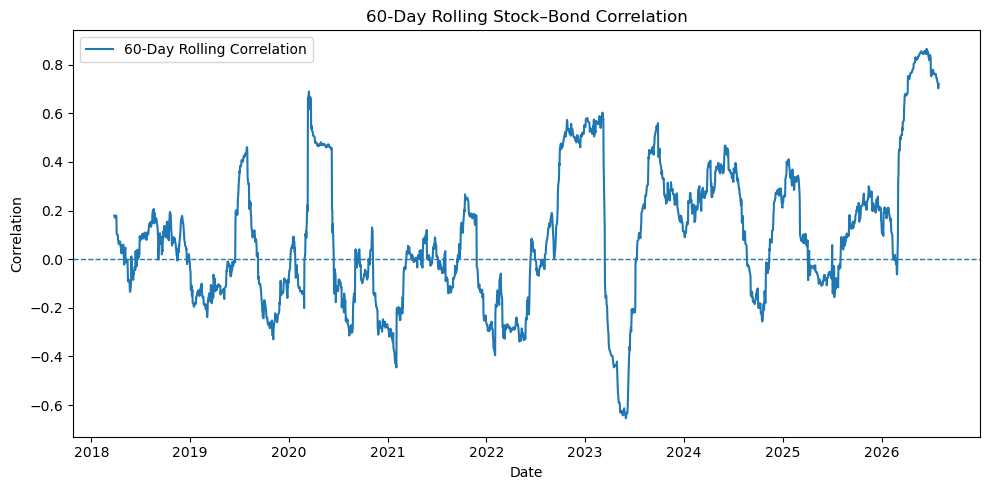

In [155]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    rolling_corr.index,
    rolling_corr,
    label="60-Day Rolling Correlation"
)

ax.axhline(
    0,
    linewidth=1,
    linestyle="--"
)

ax.set_title(
    "60-Day Rolling Stock–Bond Correlation"
)

ax.set_ylabel("Correlation")
ax.set_xlabel("Date")

ax.legend()

plt.tight_layout()

plt.savefig(
    "../figures/rolling_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Figure 2 — Euro Area Inflation and ECB Policy Rate

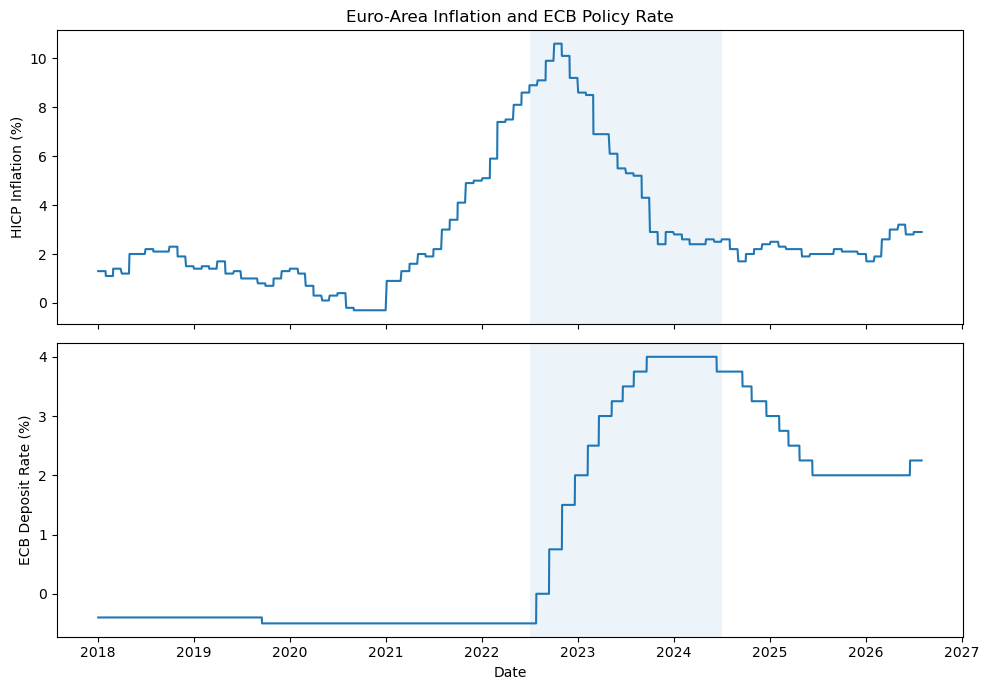

In [156]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True
)

# Inflation
axes[0].plot(
    returns.index,
    returns["Inflation"]
)

axes[0].set_title(
    "Euro-Area Inflation and ECB Policy Rate"
)

axes[0].set_ylabel(
    "HICP Inflation (%)"
)

# ECB policy rate
axes[1].plot(
    returns.index,
    returns["ECB_Rate"]
)

axes[1].set_ylabel(
    "ECB Deposit Rate (%)"
)

axes[1].set_xlabel(
    "Date"
)

# Highlight the main tightening period
for ax in axes:
    ax.axvspan(
        pd.Timestamp("2022-07-01"),
        pd.Timestamp("2024-06-30"),
        alpha=0.08
    )

plt.tight_layout()

plt.savefig(
    "../figures/macro_environment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Figure 3 — Drawdown: Stock, Bond, and 60/40 Portfolio

In [157]:
#full-sample drawdown definition
stock_drawdown = (
    cumulative_all["Stock"]
    / cumulative_all["Stock"].cummax()
    - 1
)

bond_drawdown = (
    cumulative_all["Bond"]
    / cumulative_all["Bond"].cummax()
    - 1
)

portfolio_drawdown = (
    cumulative_all["Portfolio_60_40"]
    / cumulative_all["Portfolio_60_40"].cummax()
    - 1
)

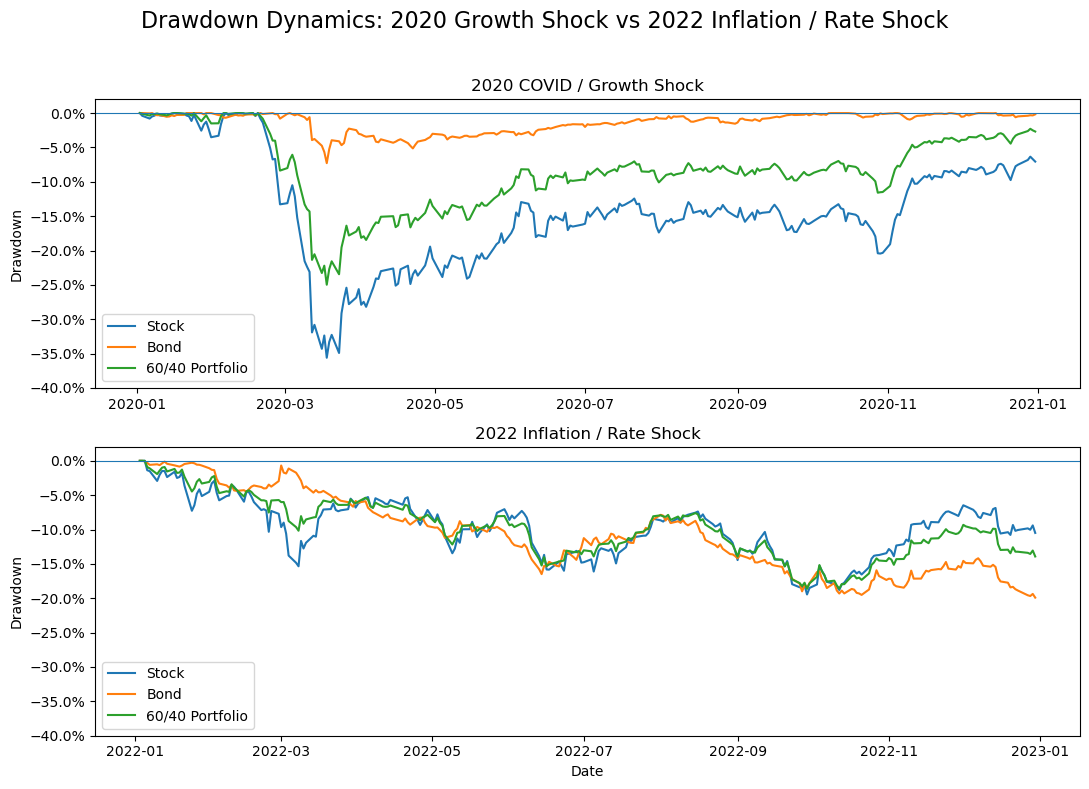

In [158]:
period_2020 = cumulative_all.loc["2020-01-01":"2020-12-31"]
period_2022 = cumulative_all.loc["2022-01-01":"2022-12-31"]

# 2020 drawdown series
stock_dd_2020_series = (
    period_2020["Stock"]
    / period_2020["Stock"].cummax()
    - 1
)

bond_dd_2020_series = (
    period_2020["Bond"]
    / period_2020["Bond"].cummax()
    - 1
)

portfolio_dd_2020_series = (
    period_2020["Portfolio_60_40"]
    / period_2020["Portfolio_60_40"].cummax()
    - 1
)


# 2022 drawdown series
stock_dd_2022_series = (
    period_2022["Stock"]
    / period_2022["Stock"].cummax()
    - 1
)

bond_dd_2022_series = (
    period_2022["Bond"]
    / period_2022["Bond"].cummax()
    - 1
)

portfolio_dd_2022_series = (
    period_2022["Portfolio_60_40"]
    / period_2022["Portfolio_60_40"].cummax()
    - 1
)


from matplotlib.ticker import PercentFormatter

# Define year-specific periods
period_2020 = cumulative_all.loc["2020-01-01":"2020-12-31"]
period_2022 = cumulative_all.loc["2022-01-01":"2022-12-31"]


# 2020 drawdown series
stock_dd_2020_series = (
    period_2020["Stock"]
    / period_2020["Stock"].cummax()
    - 1
)

bond_dd_2020_series = (
    period_2020["Bond"]
    / period_2020["Bond"].cummax()
    - 1
)

portfolio_dd_2020_series = (
    period_2020["Portfolio_60_40"]
    / period_2020["Portfolio_60_40"].cummax()
    - 1
)


# 2022 drawdown series
stock_dd_2022_series = (
    period_2022["Stock"]
    / period_2022["Stock"].cummax()
    - 1
)

bond_dd_2022_series = (
    period_2022["Bond"]
    / period_2022["Bond"].cummax()
    - 1
)

portfolio_dd_2022_series = (
    period_2022["Portfolio_60_40"]
    / period_2022["Portfolio_60_40"].cummax()
    - 1
)


# Plot
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharey=True
)

fig.suptitle(
    "Drawdown Dynamics: 2020 Growth Shock vs 2022 Inflation / Rate Shock",
    fontsize=16
)


# 2020
axes[0].plot(stock_dd_2020_series, label="Stock")
axes[0].plot(bond_dd_2020_series, label="Bond")
axes[0].plot(portfolio_dd_2020_series, label="60/40 Portfolio")

axes[0].set_title("2020 COVID / Growth Shock")
axes[0].set_ylabel("Drawdown")
axes[0].set_ylim(-0.40, 0.02)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].axhline(0, linewidth=0.8)
axes[0].legend()


# 2022
axes[1].plot(stock_dd_2022_series, label="Stock")
axes[1].plot(bond_dd_2022_series, label="Bond")
axes[1].plot(portfolio_dd_2022_series, label="60/40 Portfolio")

axes[1].set_title("2022 Inflation / Rate Shock")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_ylim(-0.40, 0.02)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].axhline(0, linewidth=0.8)
axes[1].legend()


plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "../figures/drawdown_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.3 Regime Comparison Summary

In [159]:
regime_summary = pd.DataFrame({
    "Correlation": [
        returns.loc[
            returns["High_Inflation"],
            "Stock"
        ].corr(
            returns.loc[
                returns["High_Inflation"],
                "Bond"
            ]
        ),

        returns.loc[
            ~returns["High_Inflation"],
            "Stock"
        ].corr(
            returns.loc[
                ~returns["High_Inflation"],
                "Bond"
            ]
        ),

        returns.loc[
            returns["Hiking_Regime"],
            "Stock"
        ].corr(
            returns.loc[
                returns["Hiking_Regime"],
                "Bond"
            ]
        ),

        returns.loc[
            ~returns["Hiking_Regime"],
            "Stock"
        ].corr(
            returns.loc[
                ~returns["Hiking_Regime"],
                "Bond"
            ]
        )
    ]
}, index=[
    "High Inflation",
    "Normal Inflation",
    "ECB Hiking",
    "Non-Hiking"
])

regime_summary


,Correlation
High Inflation,0.065947
Normal Inflation,0.194405
ECB Hiking,0.223753
Non-Hiking,0.133455


**Interpretation:**  
A simple high-inflation threshold does not correspond to higher stock–bond correlation in this sample. However, correlation is higher during the ECB hiking regime than during non-hiking periods. This suggests that monetary tightening may be more informative than inflation level alone, although the evidence is descriptive rather than causal.

### 4.4 Research Takeaway

Stock–bond correlation is highly time-varying, but the evidence does not support a simple story in which high inflation automatically leads to higher correlation. In this sample, stock–bond correlation is higher during the ECB hiking regime than during non-hiking periods, although this relationship is descriptive rather than causal.

The clearest contrast appears in downside protection. In 2020, bonds experienced much smaller drawdowns than stocks, allowing the 60/40 portfolio to reduce maximum drawdown by about 10.6 percentage points. In 2022, bonds themselves suffered severe losses, and the 60/40 portfolio reduced maximum drawdown by only about 0.8 percentage points.

Overall, the evidence suggests that the effectiveness of stock–bond diversification depends not only on correlation, but also on whether bonds themselves remain resilient during the underlying macroeconomic shock.



## 5. Beyond Correlation: Standalone Bond Risk and Portfolio Variance

In [160]:
# --- 2020 vs 2022 Annualized Volatility ---

# Select the three return series we want to compare
assets = ["Stock", "Bond", "Portfolio_60_40"]

# Split the daily return data by year
returns_2020 = returns.loc["2020", assets]
returns_2022 = returns.loc["2022", assets]

# Annualized volatility:
# daily standard deviation × sqrt(252 trading days)
vol_2020 = returns_2020.std() * (252 ** 0.5)
vol_2022 = returns_2022.std() * (252 ** 0.5)

# Put the results into one comparison table
volatility_comparison = pd.DataFrame({
    "2020": vol_2020,
    "2022": vol_2022
})

# Convert decimals into percentages for easier interpretation
volatility_comparison_pct = volatility_comparison * 100

volatility_comparison_pct.round(2)
#bond standalone risk (annualized volatility) is increasing from 2020 to 2022


,2020,2022
Stock,28.35,18.70
Bond,6.34,10.69
Portfolio_60_40,17.92,12.48


### 5.1 Why covariance matters

Stock–bond covariance can be decomposed as:

Cov(S,B)=Corr(S,B)×σS​×σB​

where:

- Corr(S,B) = stock–bond correlation
- σS = stock volatility
- σB​ = bond volatility

This means portfolio co-movement depends not only on correlation, but also on the standalone volatility of stocks and bonds.

Therefore, a lower correlation does not necessarily imply lower covariance if bond volatility is substantially higher.

In [161]:
# --- 2020 vs 2022 Stock-Bond Covariance ---

# Daily covariance between stock and bond returns
cov_2020_daily = returns.loc["2020", ["Stock", "Bond"]].cov().loc["Stock", "Bond"]
cov_2022_daily = returns.loc["2022", ["Stock", "Bond"]].cov().loc["Stock", "Bond"]

# Annualize covariance
cov_2020_annual = cov_2020_daily * 252
cov_2022_annual = cov_2022_daily * 252

covariance_comparison = pd.Series({
    "2020": cov_2020_annual,
    "2022": cov_2022_annual
})

covariance_comparison

2020    0.005310
2022    0.002424
dtype: float64

### 5.2 Decomposing 60/40 Portfolio Risk

Portfolio variance:

σp² = ws²σs² + wb²σb² + 2 × ws × wb × Cov(S,B)

For a 60/40 portfolio:

ws = 0.6  
wb = 0.4

So:

σp² = 0.6²σs² + 0.4²σb² + 2 × 0.6 × 0.4 × Cov(S,B)

The three parts are:

1. Stock risk contribution
2. Bond risk contribution
3. Stock–bond covariance contribution

In [162]:
# --- Decompose 60/40 Portfolio Variance ---

w_stock = 0.6
w_bond = 0.4

def variance_decomposition(year):
    year_returns = returns.loc[str(year), ["Stock", "Bond"]]

    # Annualized variances
    stock_var = year_returns["Stock"].var() * 252
    bond_var = year_returns["Bond"].var() * 252

    # Annualized covariance
    stock_bond_cov = year_returns["Stock"].cov(year_returns["Bond"]) * 252

    # Three components of portfolio variance
    stock_component = (w_stock ** 2) * stock_var
    bond_component = (w_bond ** 2) * bond_var
    covariance_component = (
        2 * w_stock * w_bond * stock_bond_cov
    )

    total_variance = (
        stock_component
        + bond_component
        + covariance_component
    )

    return pd.Series({
        "Stock component": stock_component,
        "Bond component": bond_component,
        "Covariance component": covariance_component,
        "Total portfolio variance": total_variance
    })

variance_decomposition_table = pd.DataFrame({
    "2020": variance_decomposition(2020),
    "2022": variance_decomposition(2022)
})

variance_decomposition_table.round(6)

,2020,2022
Stock component,0.028925,0.012595
Bond component,0.000644,0.001827
Covariance component,0.002549,0.001163
Total portfolio variance,0.032118,0.015585


In [163]:
# --- Variance Contribution Shares ---

variance_share_table = (
    variance_decomposition_table
    .loc[
        ["Stock component", "Bond component", "Covariance component"]
    ]
    / variance_decomposition_table.loc["Total portfolio variance"]
    * 100
)

variance_share_table.round(1)

,2020,2022
Stock component,90.1,80.8
Bond component,2.0,11.7
Covariance component,7.9,7.5


### 5.3 2020 vs 2022 Risk Comparison

In [164]:
# --- Final 2020 vs 2022 Risk Summary ---

def max_drawdown_year(return_series):
    """
    Calculate max drawdown within one year.
    The cumulative wealth index resets to 1 at the beginning of the selected year.
    """
    return_series = return_series.dropna()

    cumulative = (1 + return_series).cumprod()

    # Treat initial wealth = 1 as the starting peak
    running_peak = cumulative.cummax().clip(lower=1.0)

    drawdown = cumulative / running_peak - 1

    return drawdown.min()


summary_results = {}

for year in ["2020", "2022"]:
    
    year_data = returns.loc[year, ["Stock", "Bond", "Portfolio_60_40"]]

    # 1. Stock-bond correlation
    correlation = year_data["Stock"].corr(year_data["Bond"])

    # 2. Annualized volatility
    stock_vol = year_data["Stock"].std() * (252 ** 0.5)
    bond_vol = year_data["Bond"].std() * (252 ** 0.5)
    portfolio_vol = year_data["Portfolio_60_40"].std() * (252 ** 0.5)

    # 3. Annualized covariance
    covariance = (
        year_data["Stock"].cov(year_data["Bond"]) * 252
    )

    # 4. Variance contribution shares
    stock_var = year_data["Stock"].var() * 252
    bond_var = year_data["Bond"].var() * 252

    stock_component = (0.6 ** 2) * stock_var
    bond_component = (0.4 ** 2) * bond_var
    covariance_component = 2 * 0.6 * 0.4 * covariance

    total_variance = (
        stock_component
        + bond_component
        + covariance_component
    )

    bond_variance_share = (
        bond_component / total_variance
    )

    covariance_variance_share = (
        covariance_component / total_variance
    )

    # 5. Year-specific max drawdowns
    stock_dd = max_drawdown_year(year_data["Stock"])
    bond_dd = max_drawdown_year(year_data["Bond"])
    portfolio_dd = max_drawdown_year(
        year_data["Portfolio_60_40"]
    )

    # 6. 60/40 downside protection
    protection = abs(stock_dd) - abs(portfolio_dd)

    summary_results[year] = {
        "Stock-Bond Correlation": correlation,
        "Stock Volatility": stock_vol,
        "Bond Volatility": bond_vol,
        "60/40 Volatility": portfolio_vol,
        "Bond Variance Contribution": bond_variance_share,
        "Covariance Contribution": covariance_variance_share,
        "Stock Max Drawdown": stock_dd,
        "Bond Max Drawdown": bond_dd,
        "60/40 Max Drawdown": portfolio_dd,
        "60/40 Protection": protection
    }


risk_summary = pd.DataFrame(summary_results)

risk_summary_display = risk_summary.copy()

# Convert percentage-type metrics from decimals to %
percentage_rows = [
    "Stock Volatility",
    "Bond Volatility",
    "60/40 Volatility",
    "Bond Variance Contribution",
    "Covariance Contribution",
    "Stock Max Drawdown",
    "Bond Max Drawdown",
    "60/40 Max Drawdown",
    "60/40 Protection"
]

risk_summary_display.loc[percentage_rows] *= 100

risk_summary_display.round(2)

,2020,2022
Stock-Bond Correlation,0.30,0.12
Stock Volatility,28.35,18.70
Bond Volatility,6.34,10.69
60/40 Volatility,17.92,12.48
Bond Variance Contribution,2.01,11.72
Covariance Contribution,7.94,7.46
Stock Max Drawdown,-35.60,-19.44
Bond Max Drawdown,-7.29,-20.29
60/40 Max Drawdown,-24.97,-18.64
60/40 Protection,10.63,0.81


### 5.4 Key Finding

The 2020–2022 comparison shows that diversification effectiveness cannot be explained by stock–bond correlation alone.

In 2020, stock–bond correlation was higher, but bonds remained relatively stable: bond volatility was 6.34% and bond max drawdown was only -7.29%. As a result, bonds acted as an effective portfolio buffer and the 60/40 portfolio reduced stock max drawdown by 10.63 percentage points.

In 2022, stock–bond correlation was lower, but bond standalone risk increased materially. Bond volatility rose to 10.69%, its variance contribution increased from 2.01% to 11.72%, and bond max drawdown reached -20.29%. The 60/40 portfolio therefore reduced stock max drawdown by only 0.81 percentage points.

This suggests that diversification effectiveness depends not only on co-movement, but also on the standalone risk and downside resilience of the diversifying asset.



## 6. Tail Risk: VaR and Expected Shortfall

### 6.1 Research Question

How did the tail-risk protection provided by a 60/40 portfolio differ between the 2020 and 2022 stress episodes?

### 6.2 Historical VaR 95%

In [165]:
# Select the assets used in the tail-risk comparison
assets = ["Stock", "Bond", "Portfolio_60_40"]

# Select 2020 and 2022 daily returns
returns_2020 = returns.loc["2020", assets]
returns_2022 = returns.loc["2022", assets]

# Historical VaR 95%
# 5th percentile of returns, converted into a positive loss magnitude
var_2020 = -returns_2020.quantile(0.05)
var_2022 = -returns_2022.quantile(0.05)

var_2020, var_2022
#e.g. for 2020, the 5th percentile of stock returns is -0.032, meaning that on the worst 5% of trading days, the stock lost at least 3.2%.

(Stock              0.032092
 Bond               0.004965
 Portfolio_60_40    0.018746
 Name: 0.05, dtype: float64,
 Stock              0.018207
 Bond               0.010666
 Portfolio_60_40    0.012404
 Name: 0.05, dtype: float64)

### 6.3 Historical Expected Shortfall 95%

Expected Shortfall (ES) measures the average loss conditional on returns falling within the worst 5% of historical daily outcomes.
For reporting, ES is expressed as a positive loss magnitude.

(VaR 95% = 3.21%：告诉我们进入“最差 5% 日子”的门槛大约是亏 3.21%但超过这个门槛具体亏到少不知道，所以要算ES)

In [166]:
# Historical Expected Shortfall 95% （ES95%=-average[R|R≤VaR95%]，也就是在最坏的 5% 的交易日里，平均损失是多少）
# Average return among observations at or below the 5th percentile,
# converted into a positive loss magnitude

es_2020 = -returns_2020.apply(
    lambda x: x[x <= x.quantile(0.05)].mean() #lambda 代表对 Stock、Bond、60/40 每一列都执行后面的同一个计算。
)

es_2022 = -returns_2022.apply(
    lambda x: x[x <= x.quantile(0.05)].mean()
)

es_2020, es_2022

(Stock              0.047276
 Bond               0.009872
 Portfolio_60_40    0.030495
 dtype: float64,
 Stock              0.026069
 Bond               0.013077
 Portfolio_60_40    0.017351
 dtype: float64)

In [167]:
tail_risk_summary = pd.DataFrame({
    "2020": [
        var_2020["Stock"] * 100,
        var_2020["Bond"] * 100,
        var_2020["Portfolio_60_40"] * 100,
        es_2020["Stock"] * 100,
        es_2020["Bond"] * 100,
        es_2020["Portfolio_60_40"] * 100,
        (var_2020["Stock"] - var_2020["Portfolio_60_40"]) * 100,
        (es_2020["Stock"] - es_2020["Portfolio_60_40"]) * 100
    ],
    "2022": [
        var_2022["Stock"] * 100,
        var_2022["Bond"] * 100,
        var_2022["Portfolio_60_40"] * 100,
        es_2022["Stock"] * 100,
        es_2022["Bond"] * 100,
        es_2022["Portfolio_60_40"] * 100,
        (var_2022["Stock"] - var_2022["Portfolio_60_40"]) * 100,
        (es_2022["Stock"] - es_2022["Portfolio_60_40"]) * 100
    ]
}, index=[
    "Stock VaR 95%",
    "Bond VaR 95%",
    "60/40 VaR 95%",
    "Stock ES 95%",
    "Bond ES 95%",
    "60/40 ES 95%",
    "VaR Protection",
    "ES Protection"
])

tail_risk_summary.round(2)

,2020,2022
Stock VaR 95%,3.21,1.82
Bond VaR 95%,0.50,1.07
60/40 VaR 95%,1.87,1.24
Stock ES 95%,4.73,2.61
Bond ES 95%,0.99,1.31
60/40 ES 95%,3.05,1.74
VaR Protection,1.33,0.58
ES Protection,1.68,0.87


### 6.4 Tail-Risk Interpretation

Historical VaR and Expected Shortfall show that the 60/40 portfolio reduced daily tail risk in both 2020 and 2022, but the protection was materially stronger in 2020.

VaR protection declined from 1.33 percentage points in 2020 to 0.58 percentage points in 2022, while ES protection declined from 1.68 to 0.87 percentage points.

The results therefore support the earlier drawdown evidence: bonds remained a much more effective defensive asset during the 2020 growth shock than during the 2022 inflation and monetary-tightening episode.

Importantly, the 2022 diversification breakdown was not a complete disappearance of protection. Rather, the magnitude of downside protection weakened substantially as bond standalone tail risk increased.

## 7. Robustness and Historical Stress Testing
### 7.1 Rolling-Correlation Robustness

In [168]:
# 60-day vs 120-day rolling stock-bond correlation

rolling_corr_60 = (
    returns["Stock"]
    .rolling(60)
    .corr(returns["Bond"])
)

rolling_corr_120 = (
    returns["Stock"]
    .rolling(120)
    .corr(returns["Bond"])
)

rolling_corr_robustness = pd.DataFrame({
    "60-day": rolling_corr_60,
    "120-day": rolling_corr_120
})

rolling_corr_robustness.tail()

,60-day,120-day
Date,,
2026-07-27,0.724040,0.774854
2026-07-28,0.720041,0.780388
2026-07-29,0.702951,0.781454
2026-07-30,0.714406,0.780205
2026-07-31,0.720147,0.781561


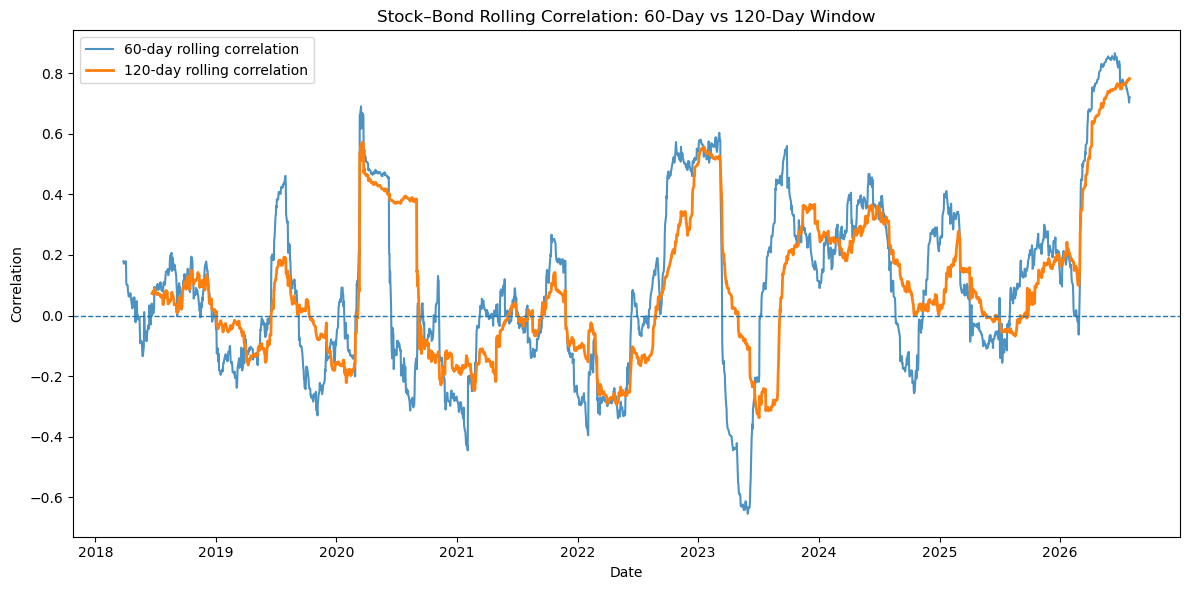

In [169]:
# Plot 60-day vs 120-day rolling correlation

plt.figure(figsize=(12, 6))

plt.plot(
    rolling_corr_robustness.index,
    rolling_corr_robustness["60-day"],
    label="60-day rolling correlation",
    alpha=0.8
)

plt.plot(
    rolling_corr_robustness.index,
    rolling_corr_robustness["120-day"],
    label="120-day rolling correlation",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Stock–Bond Rolling Correlation: 60-Day vs 120-Day Window")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../figures/rolling_correlation_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Robustness finding:**  
The main conclusion is robust to the rolling-window choice. Both the 60-day and 120-day measures show substantial time variation in stock–bond correlation and broadly similar regime patterns. The 120-day correlation is smoother and less sensitive to short-term fluctuations, but it does not overturn the original finding that the stock–bond relationship changes materially over time.

### 7.2 Inflation-Threshold Robustness


In [170]:
# Inflation threshold robustness: 4% / 5% / 6%

thresholds = [4, 5, 6]

results = []

for threshold in thresholds:
    
    valid_inflation = returns["Inflation"].notna()
    
    high_inflation = valid_inflation & (returns["Inflation"] > threshold)
    normal_inflation = valid_inflation & (returns["Inflation"] <= threshold)

    high_corr = returns.loc[
        high_inflation, ["Stock", "Bond"]
    ].corr().iloc[0, 1]

    normal_corr = returns.loc[
        normal_inflation, ["Stock", "Bond"]
    ].corr().iloc[0, 1]

    high_obs = high_inflation.sum()
    normal_obs = normal_inflation.sum()

    results.append({
        "Threshold": f">{threshold}%",
        "High Inflation Corr": high_corr,
        "Normal Inflation Corr": normal_corr,
        "High Obs": high_obs,
        "Normal Obs": normal_obs
    })

inflation_robustness = pd.DataFrame(results)

inflation_robustness

,Threshold,High Inflation Corr,Normal Inflation Corr,High Obs,Normal Obs
0,>4%,0.054711,0.207960,515,1679
1,>5%,0.065947,0.194405,428,1766
2,>6%,0.051606,0.190290,321,1873


**Robustness finding:**  
The conclusion is robust to alternative inflation thresholds. Using 4%, 5%, or 6% to define high inflation, stock–bond correlation remains substantially lower in the high-inflation regime than in the corresponding normal-inflation regime.

This result does not support the simple hypothesis that high inflation alone is associated with higher stock–bond correlation. Therefore, inflation by itself appears insufficient to explain the deterioration in diversification observed in 2022.

### 7.3 Alternative Bond ETF Robustness

In [171]:
alternative_bond = yf.download(
    "X710.DE",
    start="2018-01-01",
    end="2026-08-01",
    auto_adjust=True
)

print(alternative_bond.head())
print()
print(alternative_bond.tail())
print()
print("First date:", alternative_bond.index.min())
print("Last date:", alternative_bond.index.max())
print("Number of observations:", len(alternative_bond))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open  Volume
Ticker         X710.DE     X710.DE     X710.DE     X710.DE X710.DE
Date                                                              
2018-01-02  257.410004  258.059998  257.410004  258.059998      11
2018-01-03  257.839996  258.079987  257.839996  258.079987     160
2018-01-04  258.369995  258.369995  257.149994  257.149994      21
2018-01-05  258.369995  258.369995  258.369995  258.369995       0
2018-01-08  258.790009  258.790009  258.140015  258.220001      11

Price            Close        High         Low        Open  Volume
Ticker         X710.DE     X710.DE     X710.DE     X710.DE X710.DE
Date                                                              
2026-07-27  251.880005  252.070007  251.720001  251.720001    2006
2026-07-28  252.410004  252.660004  251.990005  252.220001     458
2026-07-29  251.369995  252.139999  251.289993  252.110001    3816
2026-07-30  251.429993  251.429993  251.000000  251.100006   

In [172]:
stock_return = stock["Close"].pct_change()
bond_return = bond["Close"].pct_change()

In [173]:
# Convert alternative bond ETF prices to daily returns

alt_bond_price = alternative_bond["Close"].squeeze() #把 alternative_bond["Close"] 这一列的 DataFrame 转换成 Series，方便后续计算 pct_change()。

alt_bond_return = alt_bond_price.pct_change().dropna()

print(alt_bond_return.head())
print()
print("Missing values:", alt_bond_return.isna().sum())
print("Number of return observations:", len(alt_bond_return))

Date
2018-01-03    0.001670
2018-01-04    0.002056
2018-01-05    0.000000
2018-01-08    0.001626
2018-01-09   -0.002319
Name: X710.DE, dtype: float64

Missing values: 0
Number of return observations: 2178


In [174]:
# Alternative bond ETF robustness: 2020 vs 2022

alt_bond_2020 = alt_bond_return.loc["2020"]
alt_bond_2022 = alt_bond_return.loc["2022"]

# Annualized volatility
alt_vol_2020 = alt_bond_2020.std() * (252 ** 0.5)
alt_vol_2022 = alt_bond_2022.std() * (252 ** 0.5)

# Year-specific drawdown
alt_cum_2020 = (1 + alt_bond_2020).cumprod()
alt_cum_2022 = (1 + alt_bond_2022).cumprod()

alt_dd_2020 = alt_cum_2020 / alt_cum_2020.cummax() - 1
alt_dd_2022 = alt_cum_2022 / alt_cum_2022.cummax() - 1

alt_max_dd_2020 = alt_dd_2020.min()
alt_max_dd_2022 = alt_dd_2022.min()

alt_bond_robustness = pd.DataFrame({
    "2020": [alt_vol_2020, alt_max_dd_2020],
    "2022": [alt_vol_2022, alt_max_dd_2022]
}, index=[
    "Annualized Volatility",
    "Max Drawdown"
])

alt_bond_robustness

,2020,2022
Annualized Volatility,0.083571,0.106470
Max Drawdown,-0.083316,-0.195771


**Alternative ETF robustness finding:**  
Using X710.DE as an alternative Eurozone 7–10 year government bond proxy produces the same qualitative result. Bond volatility increased from about 8.4% in 2020 to 10.6% in 2022, while max drawdown deteriorated from about -8.3% to -19.6%. This supports the conclusion that the deterioration in bond defensiveness in 2022 is not specific to the original IBGM.AS proxy.

### 7.4 Historical Stress Testing

We compare two historically distinct stress regimes:

- **2020 COVID / Growth Shock**
- **2022 Inflation / Rate Shock**

The objective is to assess how the defensive role of bonds differed across these two types of market stress.

In [175]:
historical_stress = pd.DataFrame({
    "2020 Growth Shock": [
        risk_summary.loc["Stock Max Drawdown", "2020"],
        risk_summary.loc["Bond Max Drawdown", "2020"],
        risk_summary.loc["60/40 Max Drawdown", "2020"],
        risk_summary.loc["60/40 Protection", "2020"],
        risk_summary.loc["Bond Volatility", "2020"]
    ],
    "2022 Inflation / Rate Shock": [
        risk_summary.loc["Stock Max Drawdown", "2022"],
        risk_summary.loc["Bond Max Drawdown", "2022"],
        risk_summary.loc["60/40 Max Drawdown", "2022"],
        risk_summary.loc["60/40 Protection", "2022"],
        risk_summary.loc["Bond Volatility", "2022"]
    ]
}, index=[
    "Stock Max Drawdown",
    "Bond Max Drawdown",
    "60/40 Max Drawdown",
    "60/40 Protection",
    "Bond Annualized Volatility"
])

historical_stress

,2020 Growth Shock,2022 Inflation / Rate Shock
Stock Max Drawdown,-0.355978,-0.194446
Bond Max Drawdown,-0.072860,-0.202852
60/40 Max Drawdown,-0.249728,-0.186354
60/40 Protection,0.106250,0.008092
Bond Annualized Volatility,0.063446,0.106851


In [176]:
# Additional historical stress-test metrics

bond_stress_ratio_2020 = (
    abs(risk_summary.loc["Bond Max Drawdown", "2020"])
    / abs(risk_summary.loc["Stock Max Drawdown", "2020"])
)

bond_stress_ratio_2022 = (
    abs(risk_summary.loc["Bond Max Drawdown", "2022"])
    / abs(risk_summary.loc["Stock Max Drawdown", "2022"])
)

protection_ratio_2020 = (
    risk_summary.loc["60/40 Protection", "2020"]
    / abs(risk_summary.loc["Stock Max Drawdown", "2020"])
)

protection_ratio_2022 = (
    risk_summary.loc["60/40 Protection", "2022"]
    / abs(risk_summary.loc["Stock Max Drawdown", "2022"])
)

stress_ratios = pd.DataFrame({
    "2020 Growth Shock": [
        bond_stress_ratio_2020,
        protection_ratio_2020
    ],
    "2022 Inflation / Rate Shock": [
        bond_stress_ratio_2022,
        protection_ratio_2022
    ]
}, index=[
    "Bond Stress Ratio",
    "Protection Ratio"
])

stress_ratios

,2020 Growth Shock,2022 Inflation / Rate Shock
Bond Stress Ratio,0.204676,1.043229
Protection Ratio,0.298474,0.041617


### 7.5 Historical Stress Interpretation

#### 2020 COVID / Growth Shock

The 2020 episode represents a growth-driven risk-off shock. The collapse in growth expectations and risk appetite generated severe equity losses, while government bonds remained relatively defensive.

The bond stress ratio was only about 0.20, meaning that the bond drawdown was roughly 20% of the equity drawdown. As a result, the 60/40 portfolio absorbed nearly 30% of the equity drawdown.

**Portfolio vulnerability:**  
The portfolio was primarily vulnerable to equity risk, while the bond allocation still functioned as a defensive diversifier.

**Future reference:**  
If a future shock is primarily growth-driven and government bonds retain defensive characteristics, a traditional stock–bond allocation may still provide meaningful downside protection.


#### 2022 Inflation / Rate Shock

The 2022 episode represents an inflation and monetary-tightening shock. High inflation and rising interest rates put pressure on both equities and government bonds.

The bond stress ratio was approximately 1.04, meaning that the bond drawdown was roughly as severe as the equity drawdown. The 60/40 portfolio offset only about 4% of the equity drawdown.

**Portfolio vulnerability:**  
The portfolio became vulnerable not only through the equity allocation, but also through the bond sleeve itself. The traditional diversifier became an additional source of portfolio stress.

**Future reference:**  
If a future environment combines persistent inflation with aggressive monetary tightening and rising bond yields, historical evidence suggests that traditional stock–bond diversification may provide much weaker downside protection.

### 7.6 Robustness Takeaway

The main findings remain broadly robust to alternative rolling-correlation windows, inflation thresholds, and an alternative government-bond ETF proxy.

The historical stress analysis also shows that diversification outcomes depend strongly on the nature of the shock. During the 2020 Growth Shock, bonds remained relatively defensive and materially reduced portfolio downside. During the 2022 Inflation / Rate Shock, bonds themselves became a major source of stress, causing 60/40 downside protection to weaken sharply.

Overall, the evidence suggests that diversification effectiveness depends not only on stock–bond co-movement, but also on whether the bond allocation retains its defensive properties under the prevailing macroeconomic regime.

## 8. Forward-Looking Stress Sensitivity

### 8.1 Research Question

**How vulnerable is a traditional 60/40 portfolio across different future stock–bond shock combinations, and when does bond stress materially impair diversification?**

The historical analysis showed that diversification depends not only on equity losses, but also on whether bonds remain defensive during periods of stress.

This section translates that finding into a forward-looking stress framework.

The shocks below are hypothetical sensitivity assumptions, not forecasts.

### 8.2 Scenario Grid

The analysis considers the following hypothetical stress ranges:

**Equity shocks:** -10%, -15%, -20%, -25%, -30%

**Bond shocks:** +10%, +5%, 0%, -5%, -10%, -15%, -20%

For each combination:

**Portfolio Shock = 0.6 × Equity Shock + 0.4 × Bond Shock**

**Diversification Protection = Portfolio_shock - Equity_shock**

**Protection Ratio = Diversification Protection / |Equity Shock|**

A higher Protection Ratio indicates stronger downside protection relative to an equity-only position.

In [177]:
equity_shocks = np.array([
    -0.10,
    -0.15,
    -0.20,
    -0.25,
    -0.30
])

bond_shocks = np.array([
     0.10,
     0.05,
     0.00,
    -0.05,
    -0.10,
    -0.15,
    -0.20
])

stress_grid = pd.MultiIndex.from_product(
    [equity_shocks, bond_shocks],
    names=["Equity_Shock", "Bond_Shock"]
).to_frame(index=False)

stress_grid["Portfolio_60_40_Shock"] = (
    0.6 * stress_grid["Equity_Shock"]
    + 0.4 * stress_grid["Bond_Shock"]
)

stress_grid["Diversification_Protection"] = (
    abs(stress_grid["Equity_Shock"])
    - abs(stress_grid["Portfolio_60_40_Shock"])
)

stress_grid["Protection_Ratio"] = (
    stress_grid["Diversification_Protection"]
    / abs(stress_grid["Equity_Shock"])
)

stress_grid

,Equity_Shock,Bond_Shock,Portfolio_60_40_Shock,Diversification_Protection,Protection_Ratio
0,-0.10,0.10,-0.02,0.08,0.800000
1,-0.10,0.05,-0.04,0.06,0.600000
2,-0.10,0.00,-0.06,0.04,0.400000
3,-0.10,-0.05,-0.08,0.02,0.200000
4,-0.10,-0.10,-0.10,0.00,0.000000
5,-0.10,-0.15,-0.12,-0.02,-0.200000
6,-0.10,-0.20,-0.14,-0.04,-0.400000
7,-0.15,0.10,-0.05,0.10,0.666667
8,-0.15,0.05,-0.07,0.08,0.533333
9,-0.15,0.00,-0.09,0.06,0.400000


In [178]:
protection_matrix = stress_grid.pivot(
    index="Equity_Shock",
    columns="Bond_Shock",
    values="Protection_Ratio"
)

protection_matrix_display = (
    protection_matrix * 100
).round(1)

protection_matrix_display.index = [
    f"{x * 100:.0f}%"
    for x in protection_matrix.index
]

protection_matrix_display.columns = [
    f"{x * 100:.0f}%"
    for x in protection_matrix.columns
]

protection_matrix_display

,-20%,-15%,-10%,-5%,0%,5%,10%
-30%,13.3,20.0,26.7,33.3,40.0,46.7,53.3
-25%,8.0,16.0,24.0,32.0,40.0,48.0,56.0
-20%,0.0,10.0,20.0,30.0,40.0,50.0,60.0
-15%,-13.3,0.0,13.3,26.7,40.0,53.3,66.7
-10%,-40.0,-20.0,0.0,20.0,40.0,60.0,80.0


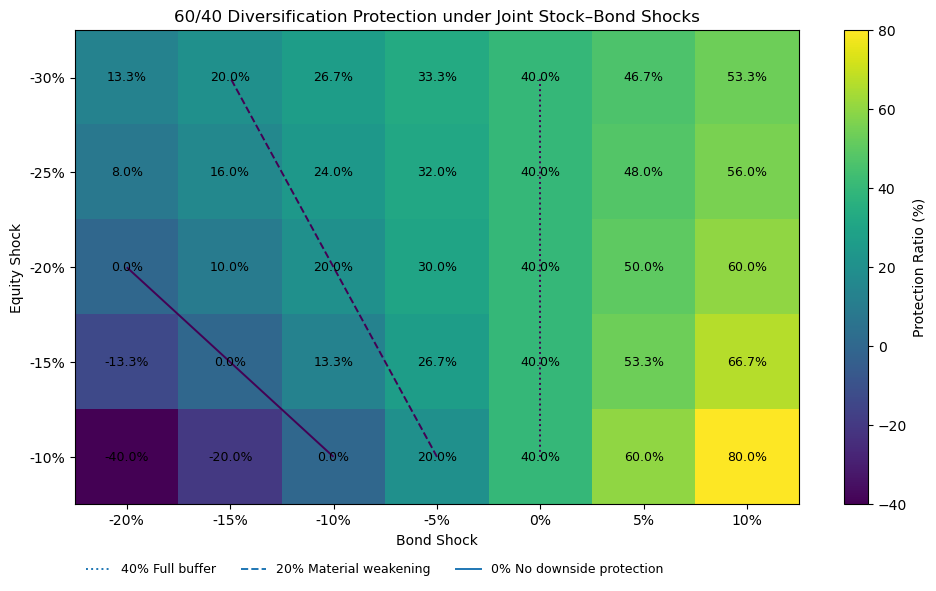

In [179]:


heatmap_data = protection_matrix_display.copy()

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    vmin=-40,
    vmax=80
)

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Bond Shock")
ax.set_ylabel("Equity Shock")

ax.set_title(
    "60/40 Diversification Protection under Joint Stock–Bond Shocks"
)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

X, Y = np.meshgrid(
    np.arange(len(heatmap_data.columns)),
    np.arange(len(heatmap_data.index))
)

ax.contour(
    X,
    Y,
    heatmap_data.values,
    levels=[0],
    linewidths=1.4,
    linestyles="solid"
)

ax.contour(
    X,
    Y,
    heatmap_data.values,
    levels=[20],
    linewidths=1.4,
    linestyles="dashed"
)

ax.contour(
    X,
    Y,
    heatmap_data.values,
    levels=[40],
    linewidths=1.4,
    linestyles="dotted"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Protection Ratio (%)")

legend_lines = [
    Line2D(
        [0], [0],
        linestyle="dotted",
        linewidth=1.4,
        label="40% Full buffer"
    ),
    Line2D(
        [0], [0],
        linestyle="dashed",
        linewidth=1.4,
        label="20% Material weakening"
    ),
    Line2D(
        [0], [0],
        linestyle="solid",
        linewidth=1.4,
        label="0% No downside protection"
    )
]

ax.legend(
    handles=legend_lines,
    loc="upper left",
    bbox_to_anchor=(0, -0.10),
    ncol=3,
    frameon=False,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "../figures/diversification_protection_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 8.3 Stress-Sensitivity Interpretation

The stress surface shows that portfolio protection depends strongly on how bonds behave relative to equities.

When bonds remain flat during an equity sell-off, the 40% bond allocation produces a **40% Protection Ratio**.

As bond losses become more severe, portfolio protection declines.

For example, under a -20% equity shock:

- Bond = 0% → Protection Ratio = 40%
- Bond = -10% → Protection Ratio = 20%
- Bond = -20% → Protection Ratio = 0%

The same equity shock can therefore produce very different portfolio outcomes depending on whether bonds remain defensive or become stressed.

### 8.4 Reverse Stress Interpretation

To summarize the stress surface, define the **Bond Stress Ratio (BSR)**:

**Bond Stress Ratio = |Bond Shock| / |Equity Shock|**

When both equities and bonds decline:

**Protection Ratio = 0.4 × (1 − Bond Stress Ratio)**

The Bond Stress Ratio therefore measures how much of the equity stress is also being experienced by the bond sleeve.

### 8.5 Diversification Protection Thresholds

For a traditional 60/40 portfolio:

- **BSR = 0 → Protection Ratio = 40%**  
  Bonds remain flat and provide the neutral 60/40 diversification benchmark.

- **BSR = 0.5 → Protection Ratio = 20%**  
  Bond losses reach half the magnitude of equity losses. Half of the neutral-bond protection has been lost.

- **BSR = 1 → Protection Ratio = 0%**  
  Bond and equity losses are equally severe, so the bond allocation no longer reduces the portfolio loss.

- **BSR > 1 → Protection Ratio < 0%**  
  Bond losses exceed equity losses and the bond allocation increases the portfolio loss relative to equities alone.

Accordingly:

- **Protection Ratio > 40%:** defensive diversification
- **Protection Ratio between 20% and 40%:** reduced but meaningful diversification
- **Protection Ratio between 0% and 20%:** materially impaired diversification
- **Protection Ratio = 0%:** no diversification benefit
- **Protection Ratio < 0%:** adverse diversification outcome

The 20% threshold is a **project-specific analytical threshold**, not an external industry standard.

### 8.6 Historical Reference Points

Using year-specific maximum drawdowns as historical severity anchors:

- **2020 Growth Shock:** Bond Stress Ratio ≈ 0.20
- **2022 Inflation / Rate Shock:** Bond Stress Ratio ≈ 1.04

These historical ratios are not simultaneous point-in-time shocks. They compare the year-specific maximum bond drawdown with the year-specific maximum equity drawdown and are used only as empirical severity anchors for the forward-looking stress framework.

The contrast is economically meaningful:

- In 2020, bond stress was only about 20% as severe as equity stress, consistent with bonds retaining a relatively defensive role.
- In 2022, bond stress was roughly as severe as equity stress, indicating a much weaker diversification structure.

The 2022 historical severity ratio therefore lies close to the region in which the forward-looking framework implies little diversification protection.

### 8.7 Forward-Looking Takeaway

The forward-looking stress analysis shows that equity-shock severity alone does not determine the effectiveness of a 60/40 portfolio.

The key vulnerability is the relative severity of bond stress.

As bond losses approach half the magnitude of equity losses, diversification protection becomes materially weaker. When bond and equity losses become similar in magnitude, the traditional 60/40 allocation provides little or no downside protection.

This extends the historical findings into a forward-looking risk-management framework:

> **The main warning signal is not simply that equities are falling, but that the bond sleeve is becoming increasingly stressed relative to equities.**